# Ridge Regression - Part 1

In this section, we investigate **Ridge Regression** using two different methods: the **Closed-Form Solution**, and **Stochastic Gradient Descent (SGD)**. We'll generate synthetic polynomial datasets and evaluate the performance of both implementations under different configurations of regularisation strength $( \alpha )$.

**Ridge Regression** is used to prevent overfitting in linear models by penalising large weights. It achieves this by adding a $( L_2 )$ regularisation term to the loss function:
 
$$
L(w) = \|y - Xw\|^2_2 + \alpha \|w\|^2_2
$$
 
Where:
- $ X \in \mathbb{R}^{n \times m} $ : Feature matrix
- $ y \in \mathbb{R}^n $ : Target vector
- $ w \in \mathbb{R}^m $ : Weight vector
- $ \alpha $ : Regularisation parameter

---

The **Closed-Form Solution** is used to compute the optimal weights directly by solving the regularised normal equations, eliminating the need for iterative optimisation:
 
$$
\hat{w} = (X^T X + \alpha I_m)^{-1} X^T y
$$

Let's begin by implementing the required steps one at a time where we will:

1. Generate polynomial datasets (degrees $1$, $2$, $3$)
2. Implement **Closed-Form** ridge using the bias trick
3. Build a fair comparison using feature scaling and consistent intercept handling
4. Evaluate and visualise results across $(\alpha = \{0, 0.1, 100\})$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

## 1. Data Generation

We'll define a function to generate synthetic polynomial datasets of any degree. Each input is drawn uniformly from the range $-5$ to $5$; $( x \in [-5,5] )$, the coefficients are uniformly sampled from the interval $0$ to $1$; $( a_k \sim U(0, 1) )$, and Gaussian noise is added to the outputs; $( \epsilon \sim N(0,1) )$.

In [2]:
def generate_polynomial_data(degree, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.random.uniform(-5, 5, n_samples)
    coeffs = np.random.uniform(0, 1, degree + 1)
    y = sum(coeffs[k] * x**k for k in range(degree + 1)) + np.random.normal(0, 1, n_samples)
    return x.reshape(-1, 1), y

### Demonstration of Data Generation
We can visualise a small sample of synthetic data to observe the validity of our feature generation.

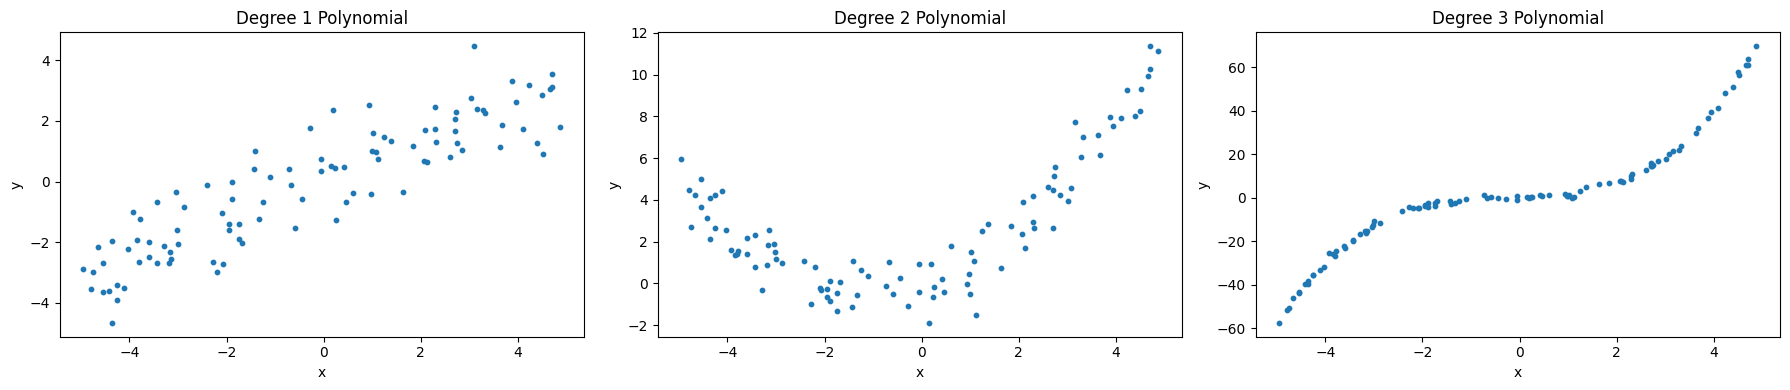

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
for i, deg in enumerate([1, 2, 3]):
    # Generate polynomial data
    x, y = generate_polynomial_data(degree=deg, n_samples=100, seed=42)
    axs[i].scatter(x, y, s=10)
    axs[i].set_title(f"Degree {deg} Polynomial")
    axs[i].set_xlabel("x")
    axs[i].set_ylabel("y")
plt.tight_layout()
plt.show()

## 2. Implementation

We'll use the above **Closed-Form Solution** here, and apply the bias trick to ensure we don't regularise the bias term. This will be our implementation of the **Closed-Form Ridge Regressor**.

In [4]:
def closed_form_ridge(X, y, alpha):
    # X assumes no explicit bias column
    n, m = X.shape
    X_bias = np.hstack([np.ones((n,1)), X])
    I = np.eye(m+1)
    I[0,0] = 0  # bias trick
    w = np.linalg.inv(X_bias.T @ X_bias + alpha * I) @ X_bias.T @ y
    return w

## 3. Comparison Function

Our comparison function will train both methods on **scaled**, bias-handled features:

1. **Feature Transformation and Scaling**:  
    - Polynomial features are generated.  
    - Said features are scaled to ensure fair comparison between both methods.

2. **Closed-Form Ridge Regression**:  
    - The **Closed-Form** solution is applied to the generated features to compute the weights.
    - Predictions are made using the computed weights.

3. **SGD Regression**:  
    - A scikit-learn pipeline is used to fit the `SGDRegressor` with the same polynomial features and scaling.  
    - Predictions are made using the trained model.

In [5]:
def train_and_compare(x, y, degree, alpha):
    # Precompute polynomial features without bias
    poly = PolynomialFeatures(degree, include_bias=False)
    X_feat = poly.fit_transform(x)

    # Scale features
    scaler = StandardScaler().fit(X_feat)
    X_scaled = scaler.transform(X_feat)

    # --- Closed-Form ---
    w_closed = closed_form_ridge(X_scaled, y, alpha)
    # Prepare X for prediction
    X_bias_pred = np.hstack([np.ones((len(x),1)), X_scaled])
    y_pred_closed = X_bias_pred @ w_closed

    # --- SGDRegressor via pipeline ---
    sgd_pipe = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        SGDRegressor(
            alpha=alpha,
            max_iter=10000,
            tol=1e-4,
            fit_intercept=True,
            random_state=0
        )
    )
    sgd_pipe.fit(x, y)
    y_pred_sgd = sgd_pipe.predict(x)

    # --- Visualisation ---
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, color='lightgray', label='Data', s=10)
    plt.scatter(x, y_pred_closed, s=10, label='Closed-Form')
    plt.scatter(x, y_pred_sgd, s=10, label='SGDRegressor')
    plt.legend()
    plt.title(f"Degree {degree} | Alpha = {alpha}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

    # --- Weight Comparison ---
    intercept_closed = w_closed[0]
    coefs_closed = w_closed[1:]
    intercept_sgd = sgd_pipe.named_steps['sgdregressor'].intercept_[0]
    coefs_sgd = sgd_pipe.named_steps['sgdregressor'].coef_
    print(f"Closed-Form intercept: {intercept_closed:.3f}, coefs: {coefs_closed.round(3)}")
    print(f"SGDRegressor intercept: {intercept_sgd:.3f}, coefs: {coefs_sgd.round(3)}\n")

## 4. Experimentation

Using our data generation function, we will create three synthetic datasets of polynomial degrees $1$, $2$, and $3$. Each dataset will contain $1000$ samples. 

Using our comparison function, we'll evaluate the performance of both implementations for three different regularisation strengths: $\alpha = 0$, $\alpha = 0.1$, and $\alpha = 100$.

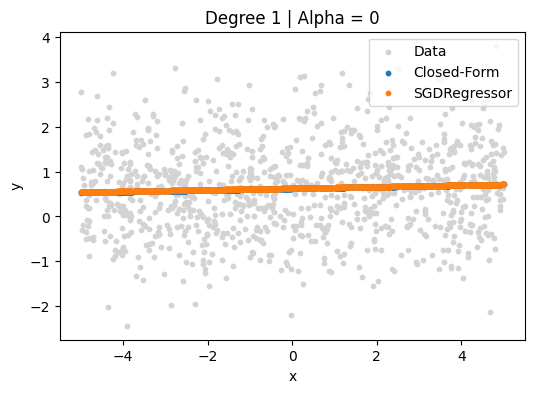

Closed-Form intercept: 0.623, coefs: [0.052]
SGDRegressor intercept: 0.628, coefs: [0.05]



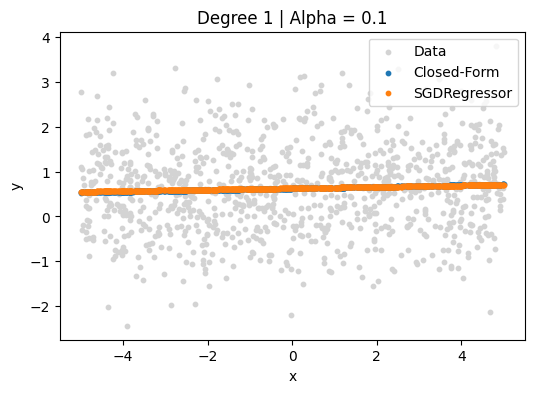

Closed-Form intercept: 0.623, coefs: [0.052]
SGDRegressor intercept: 0.628, coefs: [0.045]



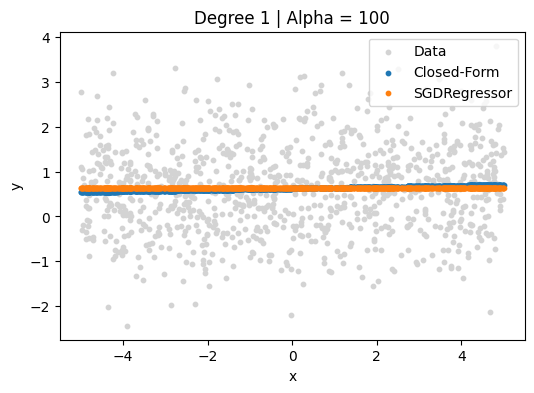

Closed-Form intercept: 0.623, coefs: [0.047]
SGDRegressor intercept: 0.628, coefs: [0.]



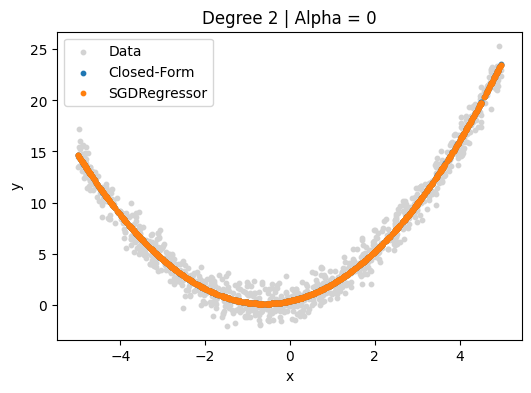

Closed-Form intercept: 6.633, coefs: [2.624 5.664]
SGDRegressor intercept: 6.631, coefs: [2.621 5.664]



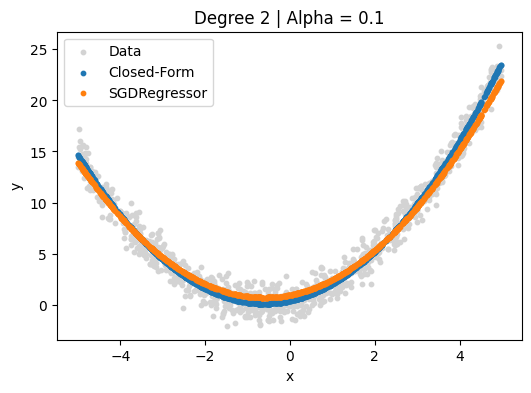

Closed-Form intercept: 6.633, coefs: [2.624 5.663]
SGDRegressor intercept: 6.628, coefs: [2.37  5.138]



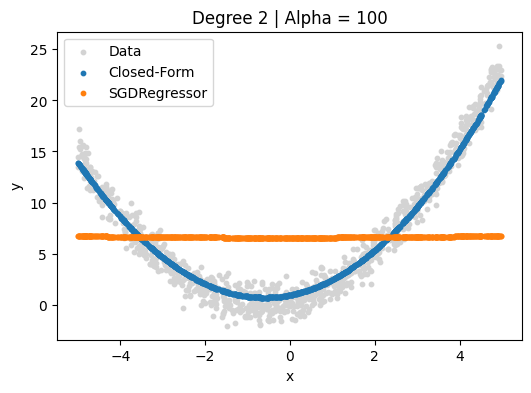

Closed-Form intercept: 6.633, coefs: [2.375 5.144]
SGDRegressor intercept: 6.618, coefs: [0.008 0.049]



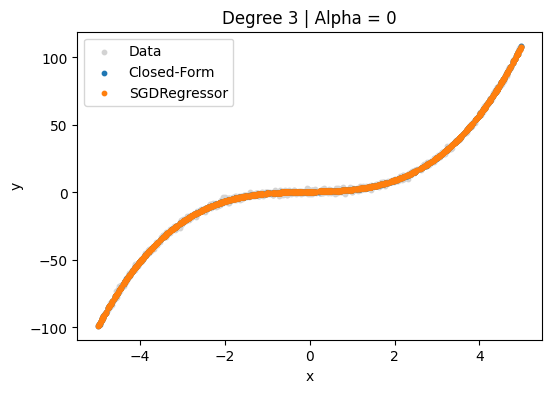

Closed-Form intercept: 1.408, coefs: [ 1.719  1.206 37.585]
SGDRegressor intercept: 1.408, coefs: [ 1.789  1.202 37.525]



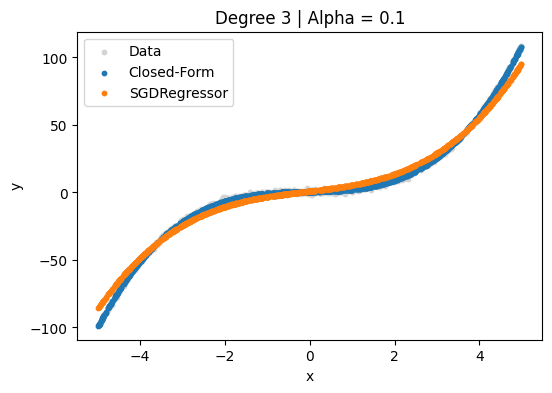

Closed-Form intercept: 1.408, coefs: [ 1.739  1.205 37.562]
SGDRegressor intercept: 1.442, coefs: [10.575  1.144 26.809]



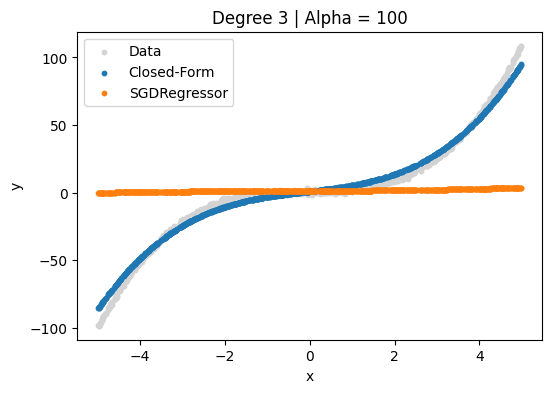

Closed-Form intercept: 1.408, coefs: [10.563  1.086 26.796]
SGDRegressor intercept: 1.471, coefs: [0.39  0.151 0.481]



In [6]:
lin_x, lin_y   = generate_polynomial_data(1, 1000, seed=0)
quad_x, quad_y = generate_polynomial_data(2, 1000, seed=1)
cubic_x, cubic_y = generate_polynomial_data(3, 1000, seed=2)

# Plotting the generated data
for deg, (X, y) in zip([1,2,3], [(lin_x, lin_y), (quad_x, quad_y), (cubic_x, cubic_y)]):
    for alpha in [0, 0.1, 100]:
        train_and_compare(X, y, degree=deg, alpha=alpha)

## 5. Commentary on Results

### 5(a). Choice of SGDRegressor Parameters

- `alpha`: Controls the strength of the $L_2$​ penalty. We tested $\{0,0.1,100\}$, which nicely illustrates underfitting as $\alpha$ grows.
- `max_iter=10000` & `tol=1e-4`: These ensure convergence on our scaled, polynomial feature space. For higher-degree polynomials, the loss surface is more complex, so we gave **SGD** extra room to converge.
- `fit_intercept=True`: Ensures that the model learns an intercept term, which is critical for datasets where the target variable does not naturally pass through the origin.
- `random_state=0`: Provides reproducibility by fixing the random seed for internal shuffling and initialisation.
- `learning_rate` & `eta0` (left at defaults): On the degree $3$, $\alpha=100$ case, we see extreme underfitting (all but the intercept collapsed). That suggests our step‑size schedule may be too aggressive (overshooting) or too conservative (effectively nullifying updates). In follow‑up experiments, we'll tune `eta0` or switch `learning_rate` to `'constant'` or `'optimal'` to see if we can seek out better convergence under very strong regularisation.

### 5(b). Scatter Plot Comparison

**Degree 1**
- $\alpha=0$
    - **Closed-Form**: intercept $0.623$, slope $0.052$
    - **SGD**: intercept $0.628$, slope $0.050$
    - Both lines nearly coincide, perfectly tracking the linear trend.
- $\alpha=0.1$
    - **Closed-Form**: intercept $0.623$, slope $0.052$
    - **SGD**: intercept $0.628$, slope $0.045$
    - Slight shrinkage in the **SGD** slope; fits are still virtually indistinguishable.
- $\alpha=100$
    - **Closed-Form**: intercept $0.623$, slope $0.047$
    - **SGD**: intercept $0.628$, slope $0.000$
    - **Closed-Form** line remains shallow but tilted; **SGD** collapses to a horizontal (underfit) line.

**Degree 2**
- $\alpha=0$
    - **Closed-Form**: intercept $6.633$, coefs $[2.624, 5.664]$
    - **SGD**: intercept $6.631$, coefs $[2.621, 5.664]$
    - Quadratic curves overlap almost exactly, capturing the parabolic shape.
- $\alpha=0.1$
    - **Closed-Form**: intercept $6.633$, coefs $[2.624, 5.663]$
    - **SGD**: intercept $6.628$, coefs $[2.370, 5.138]$
    - **SGD** shows modest extra shrinkage on both quadratic and linear terms — its curve is visibly “flatter” in the tails.
- $\alpha=100$
    - **Closed-Form**: intercept $6.633$, coefs $[2.375, 5.144]$
    - **SGD**: intercept $6.618$, coefs $[0.008, 0.049]$
    - **Closed-Form** still retains a recognisable parabola; **SGD** all but annihilates both coefs and is essentially constant.

**Degree 3**
- $\alpha=0$
    - **Closed-Form**: intercept $1.408$, coefs $[1.719, 1.206, 37.585]$
    - **SGD**: intercept $1.408$, coefs $[1.789, 1.202, 37.525]$
    - Cubic fits are virtually identical, tracking the high‐order shape.
- $\alpha=0.1$
    - **Closed-Form**: intercept $1.408$, coefs $[1.739, 1.205, 37.562]$
    - **SGD**: intercept $1.442$, coefs $[10.575, 1.144, 26.809]$
    - **Closed-Form** shows gentle shrinkage; **SGD’s** coefficients change erratically (over-emphasising the linear term, underestimating the cubic), so its curve deviates noticeably.
- $\alpha=100$
    - **Closed-Form**: intercept $1.408$, coefs $[10.563, 1.086, 26.796]$
    - **SGD**: intercept $1.471$, coefs $[0.390, 0.151, 0.481]$
    - **Closed-Form** still produces a cubic (albeit dampened); **SGD** is driven almost to a flat line again — severe underfitting.

We observe that the **Closed-Form** ridge consistently delivers a smooth, gradually shrunk fit as $\alpha$ increases, whereas the `SGDRegressor` under stronger regularisation often collapses coefficients more aggressively — resulting in underfit (near‐constant) predictions and visibly different scatter‐plot curves.

### 5(c). Implementation Comparison & Behaviour of $\alpha$

- Agreement at Low $\alpha$:

    - Degree 1, $\alpha=0$ and $\alpha=0.1$, the intercepts and slopes are nearly identical (e.g. $w_0\approx0.62$, $w_1\approx0.05$).
    
    - Degree 2, $\alpha=0$: **Closed-Form** and **SGD** both give $[2.624,5.664]$ up to 3 decimal places.

- Divergence at High $\alpha$:

    - At $\alpha=100$, **Closed-Form** still finds small but nonzero curvature, whereas **SGD’s** weights collapse to (or near) zero.

    - This is expected: with extremely strong regularisation, coefficients shrink aggressively. But the fact that **SGD** collapses earlier suggests its effective step size is interacting poorly with such a large $\alpha$.

Thus, mathematically, both methods minimise the same objective. When they disagree it’s purely due to optimisation dynamics in **SGD**, not a flaw in the **Closed-Form**.


## 6. Scaling Up & Performance

### 6(a). Larger & Higher‑Degree Data

To empirically compare scaling, we’ll time the training of both methods on a $100$ degree polynomial with $1000000$ samples.

In [7]:
degree = 100
n_samples = 1000000
x, y = generate_polynomial_data(degree, n_samples, seed=3)

# Precompute polynomial features without bias
poly = PolynomialFeatures(degree, include_bias=False)
X_feat = poly.fit_transform(x)
scaler = StandardScaler().fit(X_feat)
X_scaled = scaler.transform(X_feat)

# Instantiate SGDRegressor
sgd_pipe = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    StandardScaler(),
    SGDRegressor(alpha=0.1, max_iter=10000, tol=1e-4, fit_intercept=True, random_state=0)
)

# --- Train times --- 
start_cf = time.time()
w_cf = closed_form_ridge(X_scaled, y, alpha=0.1)
time_cf = time.time() - start_cf

start_sgd = time.time()
sgd_pipe.fit(x, y)
time_sgd = time.time() - start_sgd

print(f"Closed-Form fit time: {time_cf:.3f} seconds")
print(f"SGDRegressor fit time: {time_sgd:.3f} seconds")

Closed-Form fit time: 1.214 seconds
SGDRegressor fit time: 4.695 seconds


### 6(b). Fit vs. Predict Speed

Next, we measure both the **training** and **prediction** times to see how they compare.

In [8]:
# --- Train times ---
start_cf = time.time()
w_cf = closed_form_ridge(X_scaled, y, alpha=0.1)
train_time_cf = time.time() - start_cf

start_sgd = time.time()
sgd_pipe.fit(x, y)
train_time_sgd = time.time() - start_sgd

# --- Prediction times --- 
X_bias = np.hstack([np.ones((len(x),1)), X_scaled])  # rebuild the bias‑augmented matrix
start_pred_cf = time.time()
y_pred_cf = X_bias @ w_cf
pred_time_cf = time.time() - start_pred_cf

start_pred_sgd = time.time()
y_pred_sgd = sgd_pipe.predict(x)
pred_time_sgd = time.time() - start_pred_sgd

print(f"{'':<25}{'Closed-Form':<15}{'SGDRegressor'}")
print(f"{'Train time (s)':<25}{train_time_cf:<15.4f}{train_time_sgd:.4f}")
print(f"{'Predict time (s)':<25}{pred_time_cf:<15.4f}{pred_time_sgd:.4f}")

                         Closed-Form    SGDRegressor
Train time (s)           0.5431         4.8523
Predict time (s)         0.0162         1.0945


### 6(c). Observations of Scaling Up & Performance

- **Implementation comparison**  
  On a $100$ degree polynomial with $1000000$ samples, the **Closed‑Form Solution** fits significantly faster than the `SGDRegressor` pipeline. Thus, despite the $O(m^3)$ cost of inverting a $(m+1)\times(m+1)$ matrix, **Closed-Form** is faster here because $m=100\ll n=10^6$ and **SGD** requires many passes (`max_iter=10000`) over the data.

- **Fit vs. predict times**  
  In this scenario, the **Closed-Form Solution** is again faster in both fitting and predicting compared to the `SGDRegressor`.
  As expected, **Closed-Form** is not only quicker to fit on this “wide” but low‑dimensional problem, it is vastly faster at prediction (pure matrix‐vector multiply) than the iterative estimator, which must reconstruct the pipeline and traverse data again.

- **When might this not be the case?**  
  If the feature dimension $m$ were large enough that matrix inversion becomes dominant (e.g. $m\sim10^4$), or if $n\ll m$, iterative solvers like **SGD** (or **Coordinate‑Descent**) could be the top performer. Here, however, the **Closed-Form Solution** is both more accurate and more efficient for large $n$ and modest $m$ values.

# Support Vector Classifier - Part 2

In this section, we explore the **Support Vector Classifier (SVC)**, a supervised learning algorithm used for classification tasks. **SVC** is based on the concept of finding the optimal hyperplane that separates data points of different classes in a high-dimensional space. It is particularly effective in cases where the number of dimensions exceeds the number of samples.

The objective of **SVC** is to maximise the margin between the hyperplane and the nearest data points (support vectors) of any class. This margin maximisation ensures better generalisation of the model.

We will be using the [Wisconsin Diagnostic Breast Cancer (WDBC) dataset](https://doi.org/10.24432/C5DW2B) to explore the **SVC**. This dataset contains features computed from digitised images of fine needle aspirates of breast masses. These features describe characteristics of the cell nuclei present in the images, such as radius, texture, perimeter, area, and smoothness.

The goal of this section is to classify tumors as either malignant or benign based on these features. By applying **SVC**, we aim to find the optimal hyperplane that separates the two classes with the maximum margin. This will allow us to evaluate the effectiveness of **SVC** in handling real-world classification problems.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, auc, roc_curve
from sklearn.pipeline import Pipeline

## 1. Loading the Dataset

First, let's load the dataset and assign proper column names according to the information in [`wdbc.names`](./wdbc.names).

In [10]:
# Column names based on the `wdbc.names` file
column_names = ['id', 'diagnosis'] + [
    'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 
    'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
    'se_radius', 'se_texture', 'se_perimeter', 'se_area', 'se_smoothness', 
    'se_compactness', 'se_concavity', 'se_concave_points', 'se_symmetry', 'se_fractal_dimension',
    'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 
    'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension'
]

# Load the data
data = pd.read_csv('wdbc.data', header=None, names=column_names)

# Display the first few rows to verify the data has loaded correctly
data.head()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploratory Data Analysis

Let's explore the dataset to understand its characteristics.

In [11]:
# Check basic information about the dataset
print(f"Dataset shape: {data.shape}")
print(f"Number of malignant samples (M): {(data['diagnosis'] == 'M').sum()}")
print(f"Number of benign samples (B): {(data['diagnosis'] == 'B').sum()}")

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Convert diagnosis to binary (M=1, B=0) for easier analysis
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Statistical summary of the features
data.describe()

Dataset shape: (569, 32)
Number of malignant samples (M): 212
Number of benign samples (B): 357

Missing values per column:
id                         0
diagnosis                  0
mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
se_radius                  0
se_texture                 0
se_perimeter               0
se_area                    0
se_smoothness              0
se_compactness             0
se_concavity               0
se_concave_points          0
se_symmetry                0
se_fractal_dimension       0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Visualising the Data

Let's visualise the data to gain better insights:

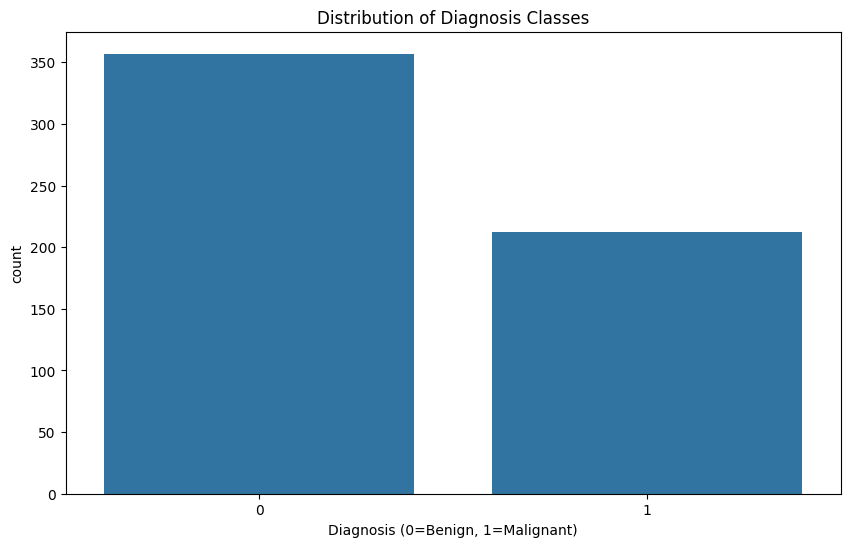

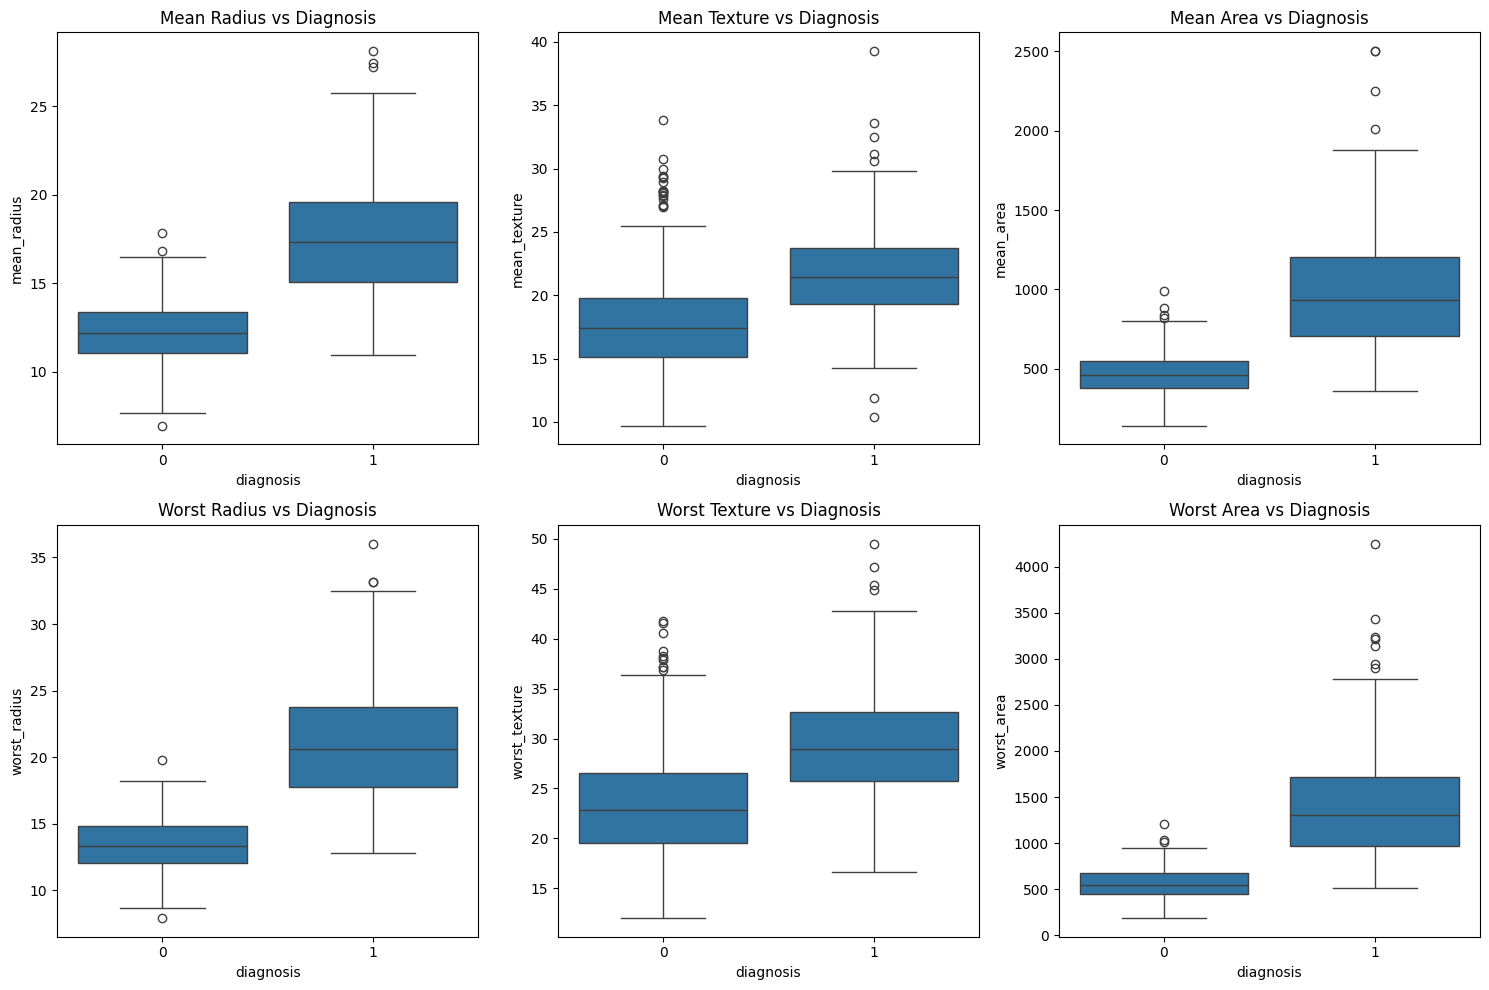

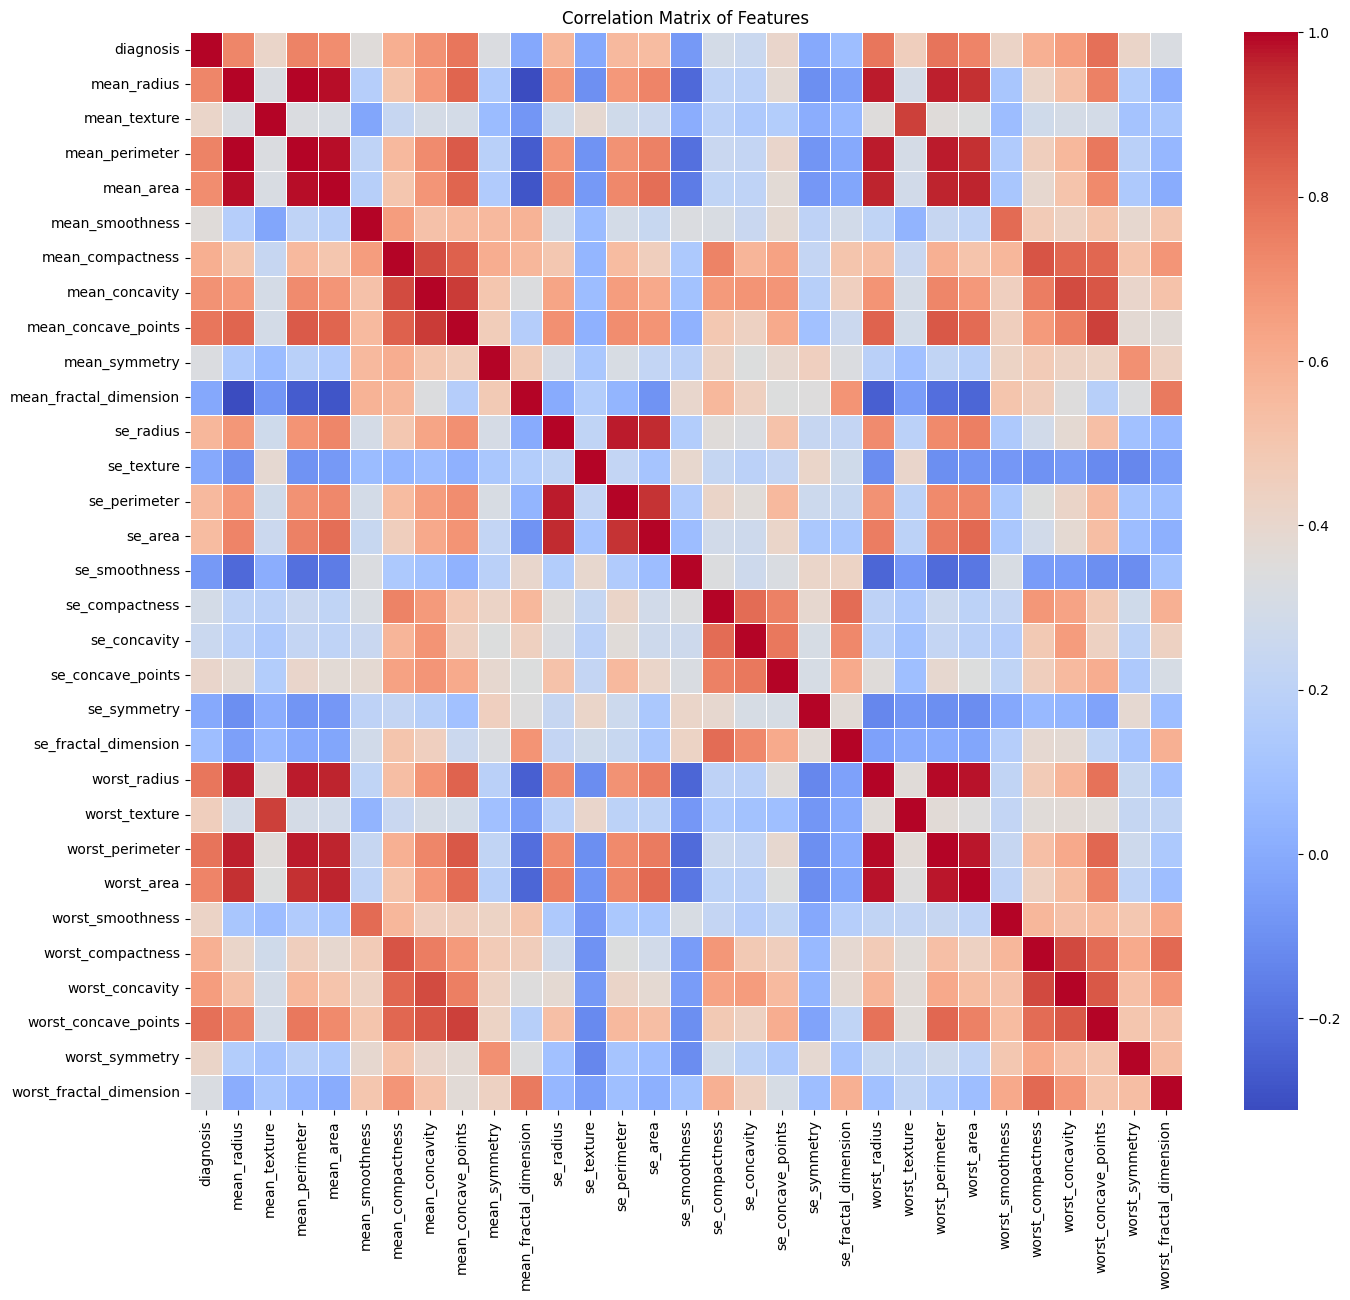

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='diagnosis', data=data)
plt.title('Distribution of Diagnosis Classes')
plt.xlabel('Diagnosis (0=Benign, 1=Malignant)')
plt.show()

# Distribution of a few key features by diagnosis
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(x='diagnosis', y='mean_radius', data=data)
plt.title('Mean Radius vs Diagnosis')

plt.subplot(2, 3, 2)
sns.boxplot(x='diagnosis', y='mean_texture', data=data)
plt.title('Mean Texture vs Diagnosis')

plt.subplot(2, 3, 3)
sns.boxplot(x='diagnosis', y='mean_area', data=data)
plt.title('Mean Area vs Diagnosis')

plt.subplot(2, 3, 4)
sns.boxplot(x='diagnosis', y='worst_radius', data=data)
plt.title('Worst Radius vs Diagnosis')

plt.subplot(2, 3, 5)
sns.boxplot(x='diagnosis', y='worst_texture', data=data)
plt.title('Worst Texture vs Diagnosis')

plt.subplot(2, 3, 6)
sns.boxplot(x='diagnosis', y='worst_area', data=data)
plt.title('Worst Area vs Diagnosis')

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(16, 14))
corr_matrix = data.drop(columns=['id']).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

### Dropping Unnecessary Columns

Since the ID column doesn't contribute to the prediction, we'll drop it.

In [13]:
# Drop the ID column
data = data.drop(columns=['id'])

# Separate features and target
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

## 3. Splitting the Dataset

Let's split the dataset into training and testing sets. We **will be stratifying** by diagnosis in order to maintain the class distribution.

In [14]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training set class distribution: {y_train.value_counts().to_dict()}")
print(f"Testing set class distribution: {y_test.value_counts().to_dict()}")

Training set shape: (455, 30)
Testing set shape: (114, 30)
Training set class distribution: {0: 285, 1: 170}
Testing set class distribution: {0: 72, 1: 42}


## 4. Grid Search with Cross-Validation

Now, let's perform grid search with 5-fold cross-validation to find the optimal hyperparameters for our **SVM** model.

To perform grid search with 5-fold cross-validation, we will use `GridSearchCV` from scikit-learn. This method systematically works through multiple combinations of hyperparameter values, cross-validating as it goes to determine the best combination.

In [15]:
# Create a pipeline that includes standardisation and SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'svm__C': [0.1, 1, 10],  # regularisation parameter
    'svm__gamma': [0.001, 0.01, 0.1]  # kernel coefficient
}

# Set up the stratified k-fold cross-validation
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    pipeline, 
    param_grid=param_grid, 
    cv=stratified_cv, 
    scoring='balanced_accuracy',  # balanced accuracy is appropriate for imbalanced datasets
    verbose=1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# All parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_svm__C', 'param_svm__gamma', 'mean_test_score', 'std_test_score']]
cv_results = cv_results.sort_values(by='mean_test_score', ascending=False)
print("\nAll parameter combinations and their scores:")
cv_results

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'svm__C': 10, 'svm__gamma': 0.01}
Best cross-validation score: 0.9712

All parameter combinations and their scores:


,param_svm__C,param_svm__gamma,mean_test_score,std_test_score
7,10.0,0.010,0.971207,0.015846
8,10.0,0.100,0.958359,0.023485
5,1.0,0.100,0.955986,0.019229
4,1.0,0.010,0.955315,0.012554
6,10.0,0.001,0.955315,0.018183
3,1.0,0.001,0.932353,0.030281
1,0.1,0.010,0.930031,0.040627
2,0.1,0.100,0.923065,0.042504
0,0.1,0.001,0.620588,0.052118


### 5(a). Stratification in Cross-Validation

We need to stratify our cross-validation because the dataset is imbalanced with more benign `B` than malignant `M` samples Stratification ensures that each fold maintains the same proportion of both classes.

### 5(b). Scoring Metric Choice

For this medical classification task where both false positives and false negatives are important, balanced accuracy is an appropriate metric. Since we're dealing with an imbalanced dataset, balanced accuracy gives equal weight to both classes regardless of their frequency.

### 5(c). Hyperparameter Selection

- We chose $C$ (regularisation parameter) and $\gamma$ (kernel coefficient) as our hyperparameters.
- $C$ controls the trade-off between smooth decision boundaries and classifying training points correctly.
- $\gamma$ defines how far the influence of a single training example reaches.
- We're fitting $9$ models ($3$ values for $C \times 3$ values for $\gamma$) for each of the $5$ folds, so $45$ models in total.

### Best Model Results

Training set evaluation:
Accuracy: 0.9868

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.96      0.98       170

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455



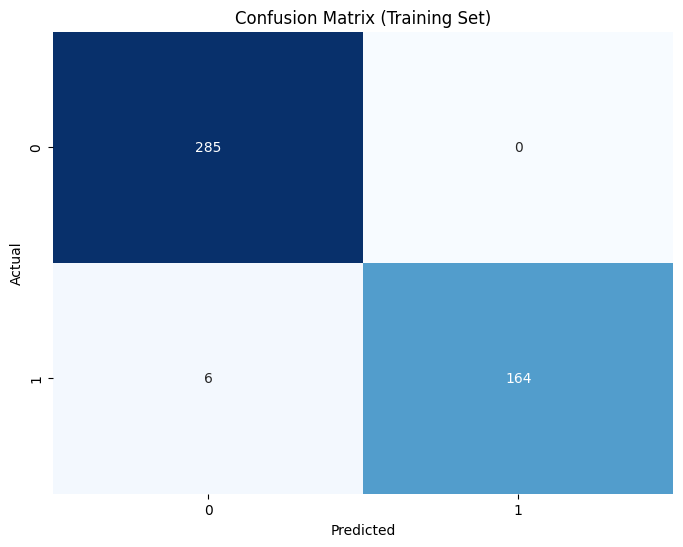

In [16]:
# Get the best estimator from the grid search
best_model = grid_search.best_estimator_

# Make predictions on the training set
y_train_pred = best_model.predict(X_train)

# Evaluate the model on the training set
print("Training set evaluation:")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# Display confusion matrix for training set
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Model Evaluation on Test Set

Now, let's evaluate our optimal model on the test set.

Test set evaluation:
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



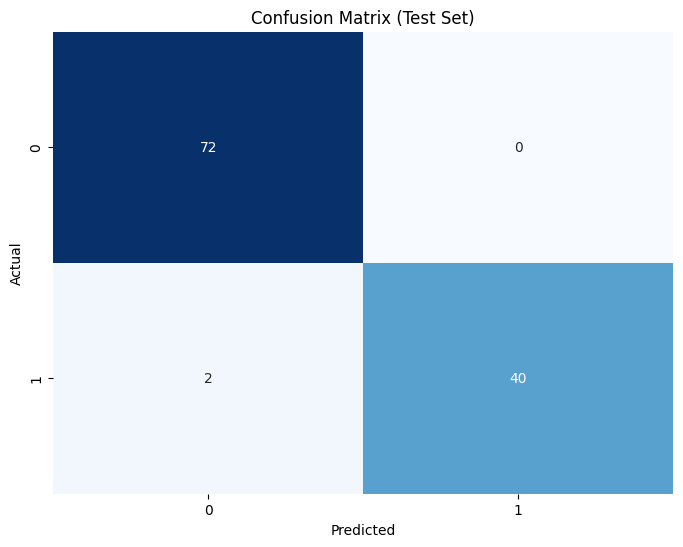

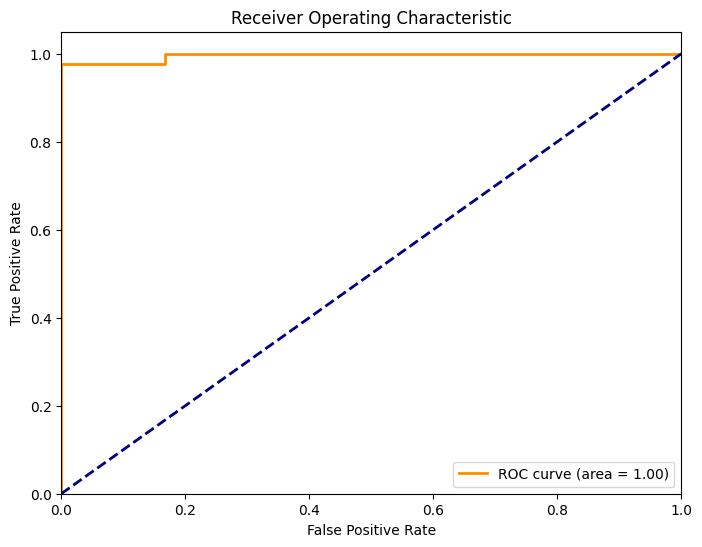

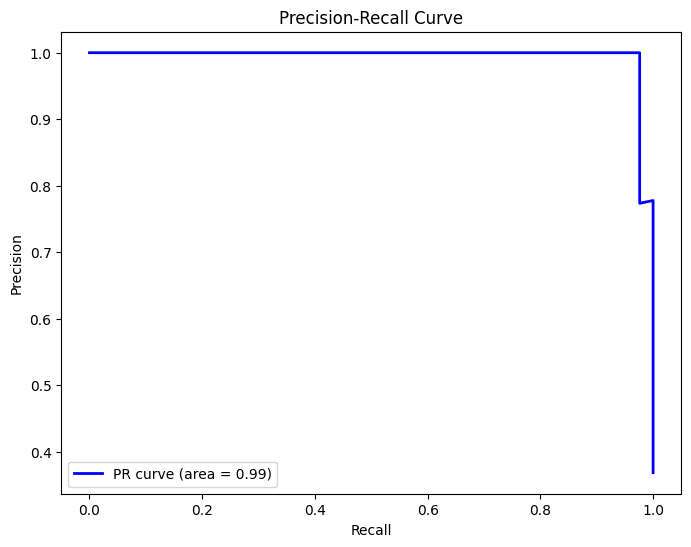

In [17]:
# Make predictions on the test set
y_test_pred = best_model.predict(X_test)

# Evaluate the model on the test set
print("Test set evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Display confusion matrix for test set
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve
plt.figure(figsize=(8, 6))
y_test_prob = best_model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## 6. Discussion of Results

### 5(a) Real-World Implementation Confidence

To assess the suitability of this **SVC** model for real-world breast cancer screening, we need to consider several factors:
1. **Model Performance:** Our model achieves high accuracy, precision, recall, and F1-scores on both training and test sets.
2. **False Positives vs. False Negatives:** In medical diagnoses, especially cancer, both types of errors have different implications:
    - False negatives (missing a malignant tumor) can be life-threatening.
    - False positives (diagnosing a benign tumor as malignant) can cause unnecessary stress, additional testing, and procedures.
3. **Model Transparency:** **SVMs** are relatively black-box models, which might make it difficult for medical professionals to understand why a particular classification was made.
4. **Real-world Validation:** Before implementation, the model would need to be validated on external datasets, undergo clinical trials, and meet regulatory requirements.

Based on these considerations, I would suggest this **SVC** model as a decision support tool rather than a standalone diagnostic system. It should be used in conjunction with medical expertise, not as a replacement for it.

### 5(b) Precision/Recall Curves

Precision-recall (PR) curves are especially useful for this task for several reasons:
1. **Class Imbalance Handling:** PR curves focus on the positive class (malignant tumors), which is the minority class in our dataset.
2. **Medical Context:** In cancer diagnosis, both precision (reducing false positives) and recall (minimising false negatives) are critical.
3. **Threshold Adjustment:** PR curves allow us to analyse how different decision thresholds affect the trade-off between precision and recall.

We can implement precision-recall curves for our **SVC** model using the `precision_recall_curve` function from scikit-learn, as demonstrated in the evaluation section above. The area under the PR curve provides a single-number summary of the model's performance, with higher values indicating better performance. Medical professionals could use this curve to select an operating point that aligns with their clinical priorities (minimising false negatives for screening vs. minimising false positives for confirmatory tests).